In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

plt.style.use("default")  

In [45]:
dataset_2025= pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2025.csv")
dataset_2026= pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\christ\2026.csv")
df = pd.concat([dataset_2025, dataset_2026])

In [46]:
df.head()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Chittor,Chittoor,Gur (Jaggery),NO 2,FAQ,2025-01-01,3200.0,3500.0,3500.0,74
1,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Garlic,Average,Local,2025-01-01,28000.0,30000.0,30000.0,25
2,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Ginger (Green),Green Ginger,Local,2025-01-01,7000.0,8000.0,8000.0,103
3,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Green Chilli,Green Chilly,Local,2025-01-01,4500.0,5000.0,5000.0,87
4,Tamil Nadu,The Nilgiris,Gudalur (Uzhavar Sandhai ),Mint (Pudina),Mint (Pudina),Local,2025-01-01,4500.0,5000.0,5000.0,360


In [47]:
df.columns

Index(['State', 'District', 'Market', 'Commodity', 'Variety', 'Grade',
       'Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price',
       'Commodity_Code'],
      dtype='str')

In [48]:
df['Arrival_Date'] 
pd.to_datetime(df['Arrival_Date'], errors='coerce')
data = df.sort_values('Arrival_Date')
print(df['Arrival_Date'].min(), df['Arrival_Date'].max())

2025-01-01 2026-01-26


In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 5984442 entries, 0 to 164959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   State           str    
 1   District        str    
 2   Market          str    
 3   Commodity       str    
 4   Variety         str    
 5   Grade           str    
 6   Arrival_Date    str    
 7   Min_Price       float64
 8   Max_Price       float64
 9   Modal_Price     float64
 10  Commodity_Code  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 547.9 MB


In [50]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
dtype: int64

In [51]:
df['Min_Price'].describe()

count    5.984442e+06
mean     4.018470e+03
std      6.081017e+03
min      0.000000e+00
25%      1.850000e+03
50%      3.000000e+03
75%      5.000000e+03
max      4.000000e+06
Name: Min_Price, dtype: float64

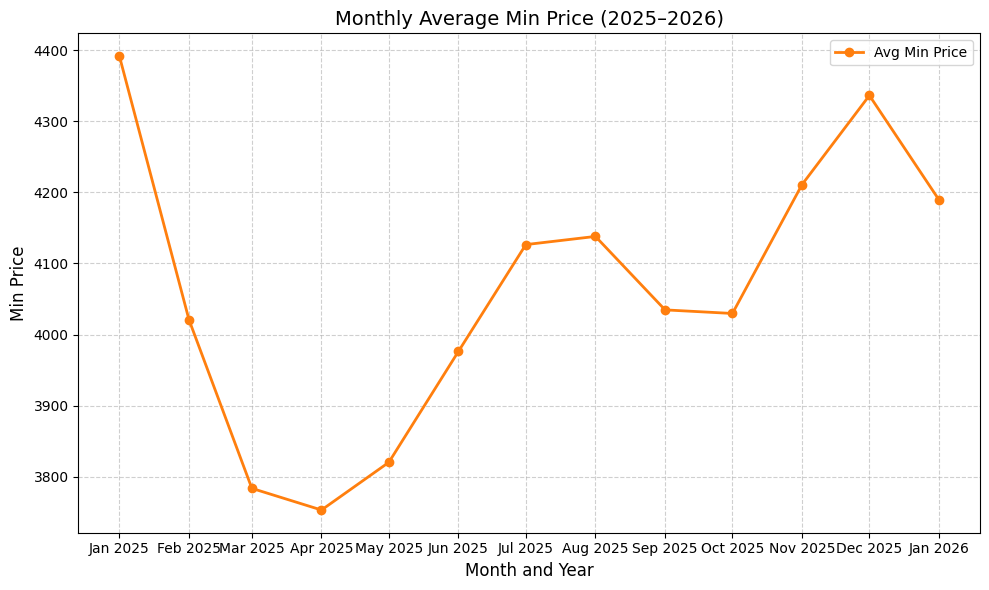

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Convert Date to datetime format
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'])

# 3. IF the Min_Price is still log-transformed predictions, uncomment the line below:
# df['Min_Price'] = np.expm1(df['Min_Price'])

# 4. Group by Month and Year (using .to_period('M') handles both)
monthly_min_avg = df.groupby(df['Arrival_Date'].dt.to_period('M'))['Min_Price'].mean()

# 5. Convert to timestamp for plotting compatibility
plot_data = monthly_min_avg.to_timestamp()

# 6. Plotting the trend
plt.figure(figsize=(10, 6))
plt.plot(plot_data.index, plot_data.values, marker='o', linestyle='-', color='#ff7f0e', linewidth=2, label='Avg Min Price')

# Customizing the labels
plt.title("Monthly Average Min Price (2025–2026)", fontsize=14)
plt.xlabel("Month and Year", fontsize=12)
plt.ylabel("Min Price", fontsize=12)

# Ensure the labels show both month and year correctly
plt.xticks(plot_data.index, [d.strftime('%b %Y') for d in plot_data.index])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
df['Min_Price'].dtype

dtype('float64')

In [54]:
print(df['Min_Price'].min())
print(df['Min_Price'].max())
print(df['Min_Price'].mean())
print(df['Min_Price'].unique()[:20])  # first 20 unique values


print(df['Min_Price'].value_counts().head(10))

0.0
4000000.0
4018.4704242039006
[ 3200. 28000.  7000.  4500.  4200.  1800.  3000.  3500.  4000.  2800.
  6500. 15000.  1500.  2000.  5600.  6000.  3800.  5500.  2500.  7850.]
Min_Price
3000.0    347514
2000.0    327418
4000.0    312564
2500.0    292110
5000.0    236850
1000.0    207377
3500.0    205783
1500.0    191883
6000.0    177700
4500.0    132427
Name: count, dtype: int64


In [55]:
top_crops = df['Commodity'].value_counts().head(10)
print("Top 10 crops:\n", top_crops)

Top 10 crops:
 Commodity
Onion                     226844
Tomato                    216087
Potato                    209354
Wheat                     193384
Brinjal                   190408
Banana                    181653
Green Chilli              180539
Bhindi (Ladies Finger)    151879
Bottle gourd              140885
Cabbage                   138396
Name: count, dtype: int64


In [56]:
df=df.copy()

In [57]:
# Strip spaces and convert to datetime safely
df['Arrival_Date'] = pd.to_datetime(df['Arrival_Date'].astype(str).str.strip(), errors='coerce')

# Check for invalid dates
invalid_dates = df['Arrival_Date'].isna().sum()
print("Number of invalid dates:", invalid_dates)

Number of invalid dates: 0


In [58]:
df = df[df['Arrival_Date'].dt.year.isin([2025, 2026])]
print("Shape after filtering:", df.shape)

Shape after filtering: (5984442, 11)


In [59]:
# Ensure numeric
df['Min_Price'] = pd.to_numeric(df['Min_Price'], errors='coerce')
print(df['Min_Price'].describe())

count    5.984442e+06
mean     4.018470e+03
std      6.081017e+03
min      0.000000e+00
25%      1.850000e+03
50%      3.000000e+03
75%      5.000000e+03
max      4.000000e+06
Name: Min_Price, dtype: float64


In [60]:
print(df.isnull().values.any())

False


In [61]:
df['Year']=df['Arrival_Date'].dt.year
print(df[['Arrival_Date','Year']].head())

  Arrival_Date  Year
0   2025-01-01  2025
1   2025-01-01  2025
2   2025-01-01  2025
3   2025-01-01  2025
4   2025-01-01  2025


In [62]:
yearly_avg = df.groupby('Year')['Min_Price'].mean()
print(yearly_avg)

Year
2025    4013.966996
2026    4189.262812
Name: Min_Price, dtype: float64


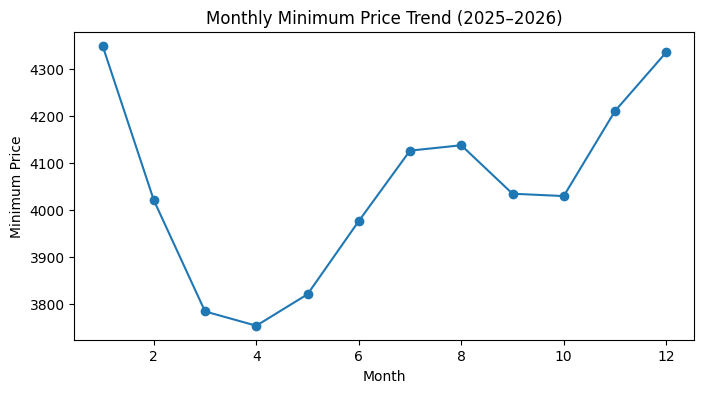

In [63]:
df['month'] = df['Arrival_Date'].dt.month
monthly_avg = df.groupby('month')['Min_Price'].mean()

plt.figure(figsize=(8,4))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title("Monthly Minimum Price Trend (2025–2026)")
plt.xlabel("Month")
plt.ylabel("Minimum Price")
plt.show()

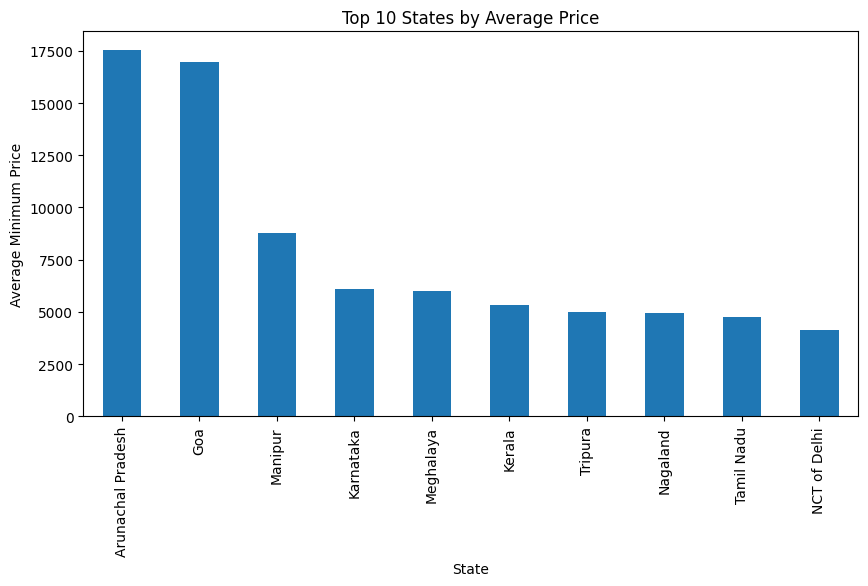

In [64]:
state_avg = df.groupby('State')['Min_Price'].mean().sort_values(ascending=False)
state_avg.head(10).plot(kind='bar', figsize=(10,5), title="Top 10 States by Average Price")
plt.xlabel("State")
plt.ylabel("Average Minimum Price")
plt.show()

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [67]:
df.describe()

,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code,Year,month
count,5984442,5.984442e+06,5.984442e+06,5.984442e+06,5.984442e+06,5.984442e+06,5.984442e+06
mean,2025-06-06 10:21:04.365698,4.018470e+03,4.715419e+03,4.481359e+03,1.041750e+02,2.025026e+03,5.388174e+00
min,2025-01-01 00:00:00,0.000000e+00,0.000000e+00,5.000000e-02,1.000000e+00,2.025000e+03,1.000000e+00
25%,2025-03-18 00:00:00,1.850000e+03,2.200000e+03,2.040000e+03,2.400000e+01,2.025000e+03,3.000000e+00
50%,2025-05-31 00:00:00,3.000000e+03,3.500000e+03,3.400000e+03,8.200000e+01,2.025000e+03,5.000000e+00
75%,2025-08-19 00:00:00,5.000000e+03,5.800000e+03,5.500000e+03,1.570000e+02,2.025000e+03,8.000000e+00
max,2026-01-26 00:00:00,4.000000e+06,4.000000e+06,4.000000e+06,4.800000e+02,2.026000e+03,1.200000e+01
std,NaN,6.081017e+03,7.022458e+03,6.596095e+03,9.569131e+01,1.582102e-01,3.025452e+00


In [68]:
sample = df.sample(200)

In [69]:
df.isnull().sum()

State             0
District          0
Market            0
Commodity         0
Variety           0
Grade             0
Arrival_Date      0
Min_Price         0
Max_Price         0
Modal_Price       0
Commodity_Code    0
Year              0
month             0
dtype: int64

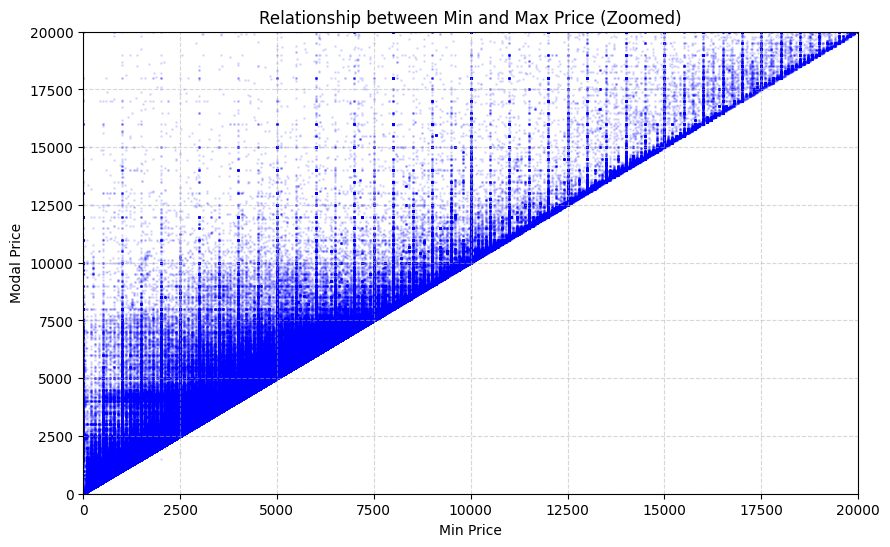

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use alpha=0.1 to make points transparent so you can see where they overlap
plt.scatter(df['Min_Price'], df['Modal_Price'], alpha=0.1,  s=1 ,color='blue')

# Zoom into the 0 to 20,000 range
plt.xlim(0, 20000)
plt.ylim(0, 20000)

plt.xlabel("Min Price")
plt.ylabel("Modal Price")
plt.title("Relationship between Min and Max Price (Zoomed)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

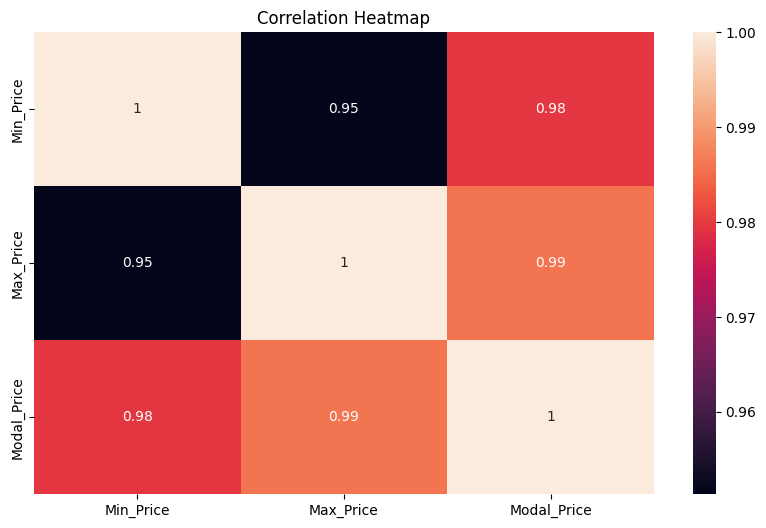

In [71]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Min_Price','Max_Price','Modal_Price']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [72]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 1. Clean the data
df_final = df.dropna(subset=['Min_Price']).copy()

# 2. Use LabelEncoder for all text columns
# We save the encoders in a dictionary so we can use them in Gradio later
encoders = {}
categorical_cols = ['State', 'District', 'Market', 'Commodity', 'Variety']

for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to avoid errors with mixed types/NaNs
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    encoders[col] = le 

# 3. Define X and y (Using only the columns you want for prediction)
X = df_final[categorical_cols + ['Max_Price', 'Modal_Price']]
y = df_final['Min_Price']

# 4. Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression(positive=True)
model.fit(X, y)

print("Model trained successfully with Label Encoding!")


Model trained successfully with Label Encoding!


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
from sklearn.linear_model import LinearRegression
df_encoded = pd.get_dummies(df, columns=['State'])
y = df_encoded['Max_Price']
X = df_encoded.drop('Max_Price', axis=1)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [75]:
y_pred = model.predict(X_test)
y_pred

array([2120.69255509, 4210.13708501, 2184.8203752 , ..., 5517.2729252 ,
       2264.11862084, 2766.11549563], shape=(1196889,))

In [76]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

0.9700992979032629


In [77]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
2443315,2340.0,2120.692555
3925216,4000.0,4210.137085
2070299,2300.0,2184.820375
1819280,2225.0,2044.104090
5614526,4500.0,4632.056920


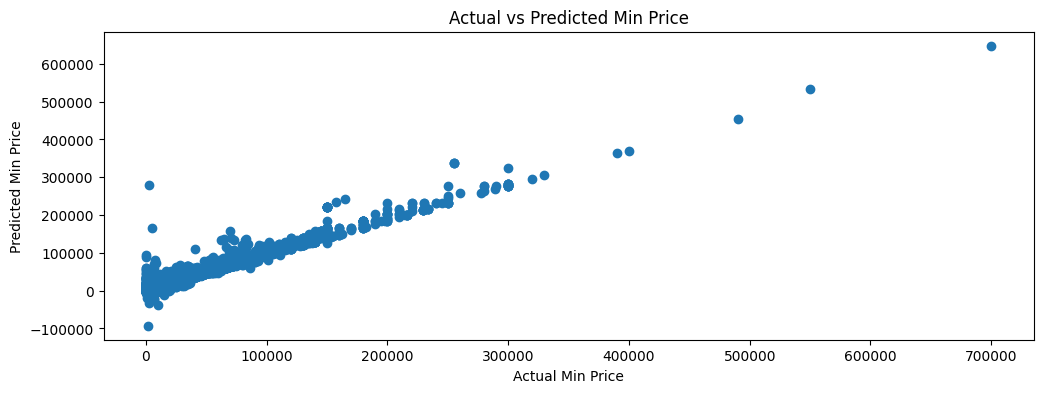

In [78]:
plt.figure(figsize=(12,4))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Min Price")
plt.ylabel("Predicted Min Price")
plt.title("Actual vs Predicted Min Price")

plt.show()

In [79]:
import gradio as gr
import numpy as np

# 1. The Prediction Logic
def predict_min_price(state, district, market, commodity, variety, max_price, modal_price):
    try:
        # Match the exact column order from your training: Categorical + Max + Modal
        encoded_values = []
        inputs_list = [state, district, market, commodity, variety]
        
        for i, col in enumerate(categorical_cols):
            le = encoders[col]
            # Transform text selection back to the number the model knows
            encoded_values.append(le.transform([str(inputs_list[i])])[0])
        
        # Combine categorical numbers with the two price inputs
        final_features = encoded_values + [max_price, modal_price]
        
        # Predict using the model
        prediction = model.predict([final_features])[0]
        
        # Return formatted HTML for a professional look
        return f"""
        <div style='text-align: center; background: #f0f9ff; padding: 20px; border-radius: 10px; border: 2px solid #bae6fd;'>
            <p style='color: #0369a1; font-size: 16px; margin: 0;'>Estimated Minimum Price</p>
            <h1 style='color: #0284c7; font-size: 36px; margin: 10px 0;'>₹{round(prediction, 2)}</h1>
        </div>
        """
    except Exception as e:
        return f"<p style='color: red;'>Error: {str(e)}</p>"

# 2. The Professional Interface
with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="MinPrice AI") as demo:
    gr.Markdown("# 🛰️ MINIMUM PRICE PREDICTION")
    gr.Markdown("Predict the minimum floor price based on market location and product type.")
    
    with gr.Row():
        # Input Section
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### 📍 Location & Product")
            state = gr.Dropdown(choices=list(encoders['State'].classes_), label="State")
            dist = gr.Dropdown(choices=list(encoders['District'].classes_), label="District")
            mkt = gr.Dropdown(choices=list(encoders['Market'].classes_), label="Market")
            comm = gr.Dropdown(choices=list(encoders['Commodity'].classes_), label="Commodity")
            var = gr.Dropdown(choices=list(encoders['Variety'].classes_), label="Variety")
            
            gr.Markdown("### 💰 Known Price Points")
            max_p = gr.Number(label="Max Price (Upper Bound)", value=0)
            mod_p = gr.Number(label="Modal Price (Average)", value=0)
            
            submit_btn = gr.Button("GENERATE PREDICTED MINIMUM PRICE", variant="primary")

        # Output Section
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Prediction Result")
            output_html = gr.HTML("<p style='text-align: center; color: gray;'>Fill inputs and click generate...</p>")
            
            # Adding a helpful tip box
            gr.Info("Note: This model uses Linear Regression based on historical market trends.")

    # Link button to function
    submit_btn.click(
        fn=predict_min_price,
        inputs=[state, dist, mkt, comm, var, max_p, mod_p],
        outputs=output_html
    )

demo.launch()

C:\Users\pc\AppData\Local\Temp\ipykernel_10228\3868696398.py:33: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="sky"), title="MinPrice AI") as demo:


Note: This model uses Linear Regression based on historical market trends.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [80]:
import pickle 
with open('min_price.pkl', 'wb') as f:
    pickle.dump(model,f)

In [81]:
import pickle

# Save these once. They will be shared by all 3 models.
le_state=pickle.dump(le, open('le_state.pkl', 'wb'))
le_dis=pickle.dump(le, open('le_district.pkl', 'wb'))
le_com=pickle.dump(le, open('le_commodity.pkl', 'wb'))